In [9]:
# # collide2v_intro
# !pip install awkward

# # emg2pose_intro
# # !pip install -e emg2pose/
# !pip install h5py==3.11.0 hydra-core==1.3.2 omegaconf joblib==1.4.2 tqdm

In [3]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras import layers, models, regularizers
from keras.optimizers import Adam
from keras.optimizers.schedules import CosineDecay
from keras.callbacks import ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import load_model
from keras import Model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#first some imports
import glob
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
# import torch
# import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

seed = 0
np.random.seed(seed)
# torch.manual_seed(seed)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

In [4]:
#load 3000 events per process
DATA_ROOT = Path("../../../hack-data/C1_HH4b/train")
N_EVENTS_PER_SAMPLE = 3000   # small subset per process -- bump this up once you trust the pipeline
N_PARTICLES_MAX = 16        # candidates kept per event (truncate/zero-pad), matches the original tutorial
CAND_FIELDS = ["pt", "eta", "phi", "dxy"]

SAMPLES = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
print("Samples found:", SAMPLES)

Samples found: ['HH_4b', 'QCD_HT250toInf', 'WJetsToLNu_13TeV-madgraphMLM-pythia8', 'WJetsToQQ_13TeV-madgraphMLM-pythia8', 'tt0123j_5f_ckm_LO_MLM_hadronic', 'tt0123j_5f_ckm_LO_MLM_leptonic', 'tt0123j_5f_ckm_LO_MLM_semiLeptonic']


In [5]:
# Read in just the first N events of a sample's first train fragment
def read_first_fragment(sample_dir: Path, n_events: int) -> ak.Array:
    frag = sorted(sample_dir.glob(f"{sample_dir.name}_*.parquet"))[0]
    pf = pq.ParquetFile(frag)
    batch = next(pf.iter_batches(batch_size=n_events, columns=["L1T_PUPPIPart", "label"]))
    return ak.from_arrow(batch)

# Reorganize the data into (N_events, N_particles, N_features) padded tensors (not variable length)
def load_physics_dataset_from_pvc(samples, n_events_per_sample=N_EVENTS_PER_SAMPLE,
                                   n_particles_max=N_PARTICLES_MAX, fields=CAND_FIELDS):
    X_parts, y_parts = [], []

    for sample in samples:
        arr = read_first_fragment(DATA_ROOT / sample, n_events_per_sample)
        cands = arr["L1T_PUPPIPart"]
        labels = ak.to_numpy(arr["label"])

        per_field = []
        for f in fields:
            padded = ak.pad_none(cands[f], n_particles_max, clip=True, axis=1)
            per_field.append(ak.to_numpy(ak.fill_none(padded, 0.0)).astype(np.float32))
        # each entry in per_field is (N_events, N_particles) -> stack into (N_events, N_particles, N_features)
        sample_X = np.stack(per_field, axis=-1)

        X_parts.append(sample_X)
        y_parts.append(labels)
        print(f"{sample}: loaded {len(arr)} events, label={labels[0]}")

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int64)
    return X, y


X, y = load_physics_dataset_from_pvc(SAMPLES)
print(X.shape, y.shape)  # (N_total_events, N_particles, N_features), (N_total_events,)
print("Class counts:", {int(c): int((y == c).sum()) for c in np.unique(y)})

HH_4b: loaded 3000 events, label=1
QCD_HT250toInf: loaded 3000 events, label=0
WJetsToLNu_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
WJetsToQQ_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
tt0123j_5f_ckm_LO_MLM_hadronic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_leptonic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_semiLeptonic: loaded 3000 events, label=2
(21000, 16, 4) (21000,)
Class counts: {0: 3000, 1: 3000, 2: 9000, 3: 6000}


In [6]:
# what is stored in the reconstructed particles `L1_PUPPIPart?
hh4b_frag = read_first_fragment(DATA_ROOT / "HH_4b", 1) #just one event
hh4b_frag["L1T_PUPPIPart"].fields 

['pt',
 'eta',
 'phi',
 'dxy',
 'dxysig',
 'pdgId',
 'charge',
 'pt_weighted',
 'puppi_weight',
 'e',
 'mass',
 'dz',
 'error_dz',
 'funique_id']

In [7]:
#preprocess and normalize etc the data
def preprocess_particles(X, pt_index=0, eta_index=1, phi_index=2, d0_index=3, eta_range=(-5.0, 5.0)):
    X_proc = X.copy()

    pt = X_proc[:, :, pt_index]
    pt_logged = np.log(pt + 1.0)
    pt_min, pt_max = pt_logged.min(), pt_logged.max()
    X_proc[:, :, pt_index] = (pt_logged - pt_min) / (pt_max - pt_min + 1e-8)

    eta_min, eta_max = eta_range
    X_proc[:, :, eta_index] = np.clip((X_proc[:, :, eta_index] - eta_min) / (eta_max - eta_min), 0.0, 1.0)

    d0 = X_proc[:, :, d0_index]
    d0_min, d0_max = d0.min(), d0.max()
    X_proc[:, :, d0_index] = (d0 - d0_min) / (d0_max - d0_min + 1e-8)

    phi = X_proc[:, :, phi_index]
    phi_cos, phi_sin = np.cos(phi), np.sin(phi)
    X_proc = np.delete(X_proc, phi_index, axis=2)
    X_proc = np.concatenate([X_proc, phi_cos[..., np.newaxis], phi_sin[..., np.newaxis]], axis=2)
    return X_proc


X_proc = preprocess_particles(X)
print(X_proc.shape)  # (N_events, N_particles, 5) -- pt, eta, dxy, cos(phi), sin(phi)

(21000, 16, 5)


In [8]:
#define our train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.4, random_state=42, stratify=y, shuffle=True
)
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.2, random_state=42, stratify=y_test, shuffle=True
)
print("train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# X_train_t = torch.from_numpy(X_train).float()
# y_train_t = torch.from_numpy(y_train).long()
# X_val_t = torch.from_numpy(X_val).float()
# y_val_t = torch.from_numpy(y_val).long()
# X_test_t = torch.from_numpy(X_test).float()
# y_test_t = torch.from_numpy(y_test).long()
# n_classes = int(y.max()) + 1

train/val/test: 12600 1680 6720


In [60]:
teacher = load_model("../mlp_best_model.keras")
teacher.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │        82,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,328,388 (8.88 MB)

 Trainable params: 776,129 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,552,259 (5.92 MB)

In [65]:
retrain = False;
from keras.callbacks import ModelCheckpoint

checkpoint_path = "mlp_best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

if retrain:
    initial_lr = 1e-3
    epochs = 20
    steps_per_epoch = X_train.shape[0] // 512
    lr_schedule = CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=epochs * steps_per_epoch,
        alpha=1e-4
    )
    
    optimizer = Adam(learning_rate=lr_schedule)

    mlp.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = mlp.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=64,  # The ratio of learning rate to batch size controls the “temperature” of the optimiser: higher values promote exploration. Temperature also affects the geometry of the minima. Paper: https://openreview.net/references/pdf?id=S1UD-XWCZ
        shuffle=True,
        callbacks=[checkpoint_cb]
    )
    
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"Final Train Accuracy: {trintermediate_layer_model = Model(
    inputs=model.input, outputs=model.get_layer('dense_1').output)
ain_acc:.3f}")
    print(f"Final Validation Accuracy: {val_acc:.3f}")
    print(f"Best model saved at: {checkpoint_path}")

SyntaxError: unterminated string literal (detected at line 41) (308649818.py, line 41)

In [66]:
from sklearn.metrics import accuracy_score
from keras.models import load_model
# teacher = mlp 
y_teacher = teacher.predict(np.ascontiguousarray(X_test))
y_test_out= y_test !=0
print('Accuracy quantized: {}'.format(accuracy_score(y_test_out, np.argmax(y_qkeras, axis=1))))

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step 
Accuracy quantized: 0.14285714285714285


In [69]:
learningLayer = "dense_10"
intermediate_layer_model = Model(
    inputs=teacher.input, outputs=teacher.get_layer(learningLayer).output)
intermediate_output_train = intermediate_layer_model.predict(X_train)
intermediate_output_val = intermediate_layer_model.predict(X_val)

394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [68]:
print(intermediate_output_train)

[[2.5636088e+08 0.0000000e+00 2.5328987e+08 ... 0.0000000e+00
  0.0000000e+00 2.4163688e+08]
 [2.9063971e+08 0.0000000e+00 2.8715795e+08 ... 0.0000000e+00
  0.0000000e+00 2.7394685e+08]
 [2.5828818e+08 0.0000000e+00 2.5519398e+08 ... 0.0000000e+00
  0.0000000e+00 2.4345341e+08]
 ...
 [2.7348762e+08 0.0000000e+00 2.7021139e+08 ... 0.0000000e+00
  0.0000000e+00 2.5777987e+08]
 [2.4739632e+08 0.0000000e+00 2.4443264e+08 ... 0.0000000e+00
  0.0000000e+00 2.3318712e+08]
 [2.6751995e+08 0.0000000e+00 2.6431520e+08 ... 0.0000000e+00
  0.0000000e+00 2.5215493e+08]]


In [72]:

input_shape = X_train.shape[1:]
# n_classes = len(set(y_train))


initial_lr = 1e-3
epochs = 100
steps_per_epoch = X_train.shape[0] // 512
lr_schedule = CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=epochs * steps_per_epoch,
    alpha=1e-4
)

optimizer = Adam(learning_rate=lr_schedule)

inputs = layers.Input(shape=input_shape)
x = layers.Flatten()(inputs)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# Fundamental theorem of learning theory: High-D embedding space can make complex data linearly separable
x = layers.Dropout(0.1)(x)

x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# Fundamental theorem of learning theory: High-D embedding space can make complex data linearly separable
x = layers.Dropout(0.1)(x)

student= models.Model(inputs,x)
student.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)


In [71]:
history = student.fit(
    X_train, intermediate_output_train,
    validation_data=(X_val, intermediate_output_val),
    epochs=epochs,
    batch_size=64,  # The ratio of learning rate to batch size controls the “temperature” of the optimiser: higher values promote exploration. Temperature also affects the geometry of the minima. Paper: https://openreview.net/references/pdf?id=S1UD-XWCZ
    shuffle=True,
    callbacks=[]
)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 27571317070888960.0000 - mae: 120087240.0000 - val_loss: 27569453055082496.0000 - val_mae: 120070688.0000
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - loss: 27571250498895872.0000 - mae: 120087128.0000 - val_loss: 27569371450703872.0000 - val_mae: 120070496.0000
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - loss: 27571164599549952.0000 - mae: 120086920.0000 - val_loss: 27569253339103232.0000 - val_mae: 120070216.0000
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - loss: 27571016423178240.0000 - mae: 120086584.0000 - val_loss: 27569109457698816.0000 - val_mae: 120069920.0000
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 27570876836741120.0000 - mae: 120086304.0000 - val_loss: 27568965576294400.0000 - val_mae: 120069616.0000
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 27570739397787648.0000 - mae: 120085952.0000 - val_loss: 27568830284824576.0000 - val_mae: 120

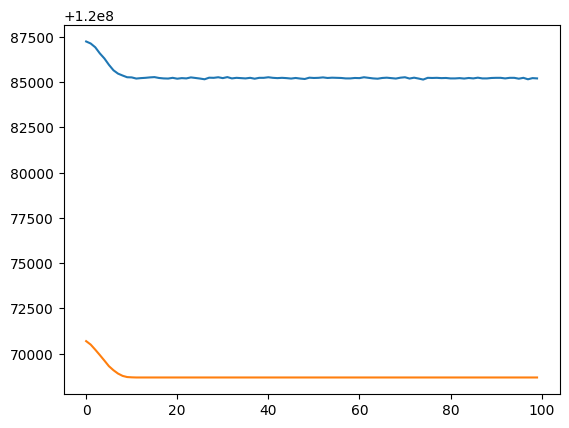

In [76]:
plt.plot(history.history["mae"])
plt.plot(history.history["val_mae"])

In [73]:
#combine student with teacher
intermediate = teacher.get_layer(learningLayer)

teacher_head = tf.keras.Model(
    inputs=intermediate.output,
    outputs=teacher.output
)

student_input = student.input
student_32 = student.output

student_with_teacher_head = tf.keras.Model(
    inputs=student_input,
    outputs=teacher_head(student_32)
)

In [74]:
from sklearn.metrics import accuracy_score
from keras.models import load_model
y_student = mlp.predict(np.ascontiguousarray(X_test))
y_test_out= y_test !=0
print('Accuracy student: {}'.format(accuracy_score(y_test_out, np.argmax(y_student, axis=1))))

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step
Accuracy student: 0.14285714285714285
